

# MidtermExam-2510 Hint Code & Setup

Midtermexam-2510 is the official hint code for the midterm. Many exam questions are based on it.

**Before the exam**

*  Mount your Google Drive in Colab.

*  Place midterm-customer.csv in a folder you can access from the Drive mount (e.g., /content/drive/MyDrive/midterm/).

* Open Midtermexam-2510, update the file path to the CSV if needed, and make sure the notebook runs end-to-end without errors.

**During the exam**

* You will run the hint code and **edit/modify/expand** it to answer the questions.


If you can run the notebook and load midterm-customer.csv from your Drive mount, you’re ready.




In [1]:
#mounnt your google dirve
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
myData = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/MidtermExam/midterm-customer.csv')
myData.head(n=5)

,CustID,Sex,Race,BirthDate,College,HouseholdSize,ZipCode,Income,Spending2020,Spending2021,NumOfOrders,DaysSinceLast,Satisfaction,Channel
0,1530016,Female,Black,12/16/1986,Yes,5,90047,53000,287.0,241.0,3,101,Very Dissatisfied,SM
1,1531136,Male,White,5/9/1993,Yes,5,90026,94000,1227.0,843.0,12,262,Neutral,TV
2,1532160,Male,Black,5/22/1966,Yes,2,90027,64000,523.0,719.0,9,122,Very Satisfied,TV
3,1532307,Male,White,9/16/1964,Yes,4,90029,60000,516.0,582.0,13,129,Very Dissatisfied,SM
4,1532356,Female,Hispanic,7/15/1964,No,5,90017,47000,555.0,845.0,7,97,Very Dissatisfied,Web


In [ ]:
q1 = myData['NumOfOrders'].quantile(0.25) # Q1 of the midterm score
q2 = myData['NumOfOrders'].quantile(0.50) #Q2 (median value)
q3 = myData['NumOfOrders'].quantile(0.75) #Q3
IQR = q3 - q1

lower_fence = q1 - 1.5 * IQR
upper_fence = q3 + 1.5 * IQR


print("min:", myData['NumOfOrders'].min())
print('max:', myData['NumOfOrders'].max())
print("Q1:", q1)
print("Q2 (median):", q2)
print("Q3:", q3)
print("IQR:", IQR)

print("low_fence:", lower_fence) #Low fence value
print("High_fense:", upper_fence) #High fence value


min: 1
max: 89
Q1: 4.0
Q2 (median): 9.0
Q3: 15.0
IQR: 11.0
low_fence: -12.5
High_fense: 31.5


In [ ]:
#Mean or median of the column Income?
myData['Income'].mean() #or median(), max(), min()


np.float64(73036.5296803653)

### Row Subsetting using boolean expression



In [ ]:
#high_spending_cust = (myData['Spending2020'] > 800 ) &  (myData['Spending2021'] > 800)

high_spending_cust = myData[ (myData['Spending2020'] > 1000) |  (myData['Spending2021'] > 1000)  ]

# & --> and operator,   | --> or operator


high_spending_cust

,CustID,Sex,Race,BirthDate,College,HouseholdSize,ZipCode,Income,Spending2020,Spending2021,NumOfOrders,DaysSinceLast,Satisfaction,Channel
1,1531136,Male,White,5/9/1993,Yes,5,90026,94000,1227.0,843.0,12,262,Neutral,TV
7,1533561,Male,Hispanic,2/10/1981,Yes,5,90050,76000,1474.0,1079.0,23,122,Very Satisfied,Referral
10,1533791,Male,White,10/27/1999,Yes,1,90060,97000,828.0,1028.0,17,110,Very Dissatisfied,Web
17,1535927,Male,White,1/12/1979,Yes,1,90003,66000,1283.0,879.0,10,35,Very Satisfied,Referral
18,1536475,Male,Pacific Islander,5/17/1958,Yes,2,90019,73000,1276.0,1108.0,20,56,Neutral,Web
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,1576752,Male,Black,7/18/1968,Yes,4,90044,82000,1322.0,1241.0,11,159,Very Satisfied,TV
211,1577940,Female,Black,2/27/1973,Yes,5,90019,94000,634.0,1206.0,18,181,Somewhat Satisfied,Web
212,1578327,Male,Hispanic,8/24/1967,Yes,1,90024,49000,1015.0,760.0,11,136,Neutral,SM
214,1578525,Male,Hispanic,12/12/1963,Yes,1,90005,82000,NaN,1121.0,25,302,Somewhat Satisfied,Web


In [ ]:
high_spending_cust.shape # or len(high_spending_cust)

(64, 14)

### Groupby

In [ ]:
myData.groupby('Channel')['Spending2020'].mean()

#from this, what can we infer? socail media, TV or Web --> which one should we emphaize

,Spending2020
Channel,
Referral,629.097561
SM,673.000000
TV,693.824561
Web,597.915493


In [ ]:
#standard deviation

myData.Income.std()

24060.29388910448

### Can you find the correlation Coefficient (r) or covirance between "HouseholdSize" and "Income"?

In [ ]:
myData[['Income', 'HouseholdSize']].corr()

,Income,HouseholdSize
Income,1.000000,0.163175
HouseholdSize,0.163175,1.000000


In [ ]:
myData[['Income', 'HouseholdSize']].cov()

,Income,HouseholdSize
Income,5.788977e+08,5611.495120
HouseholdSize,5.611495e+03,2.042897


In [ ]:
# Any missing values?

myData.isnull().sum()



,0
CustID,0
Sex,0
Race,0
BirthDate,0
College,0
HouseholdSize,0
ZipCode,0
Income,0
Spending2020,7
Spending2021,5


#### How to replace the missing values? --> look at ch2.ipynb file --> fillna

In [ ]:
# replace the missing values in the column Spending2021 with its mean --> fillna

imputation = myData.Spending2021.fillna(myData.Spending2021.mean()) #still original dataframe myData remains unchanged.
imputation

#To permanently change the original data frame, myData:

# myData['Spending2021'] = myData.Spending2021.fillna(myData.Spending2021.mean()) -> Be careful! -> this will change your original dataframe forever~


,Spending2021
0,241.0
1,843.0
2,719.0
3,582.0
4,845.0
...,...
214,1121.0
215,397.0
216,514.0
217,586.0


### Additional materials for the extra credit problems

In [5]:
Gender_freq = myData['Sex'].value_counts()
Gender_freq

,count
Sex,
Male,139
Female,80


In [6]:
Gender_freq_proportion = myData['Sex'].value_counts(normalize = True)
Gender_freq_proportion

,proportion
Sex,
Male,0.634703
Female,0.365297


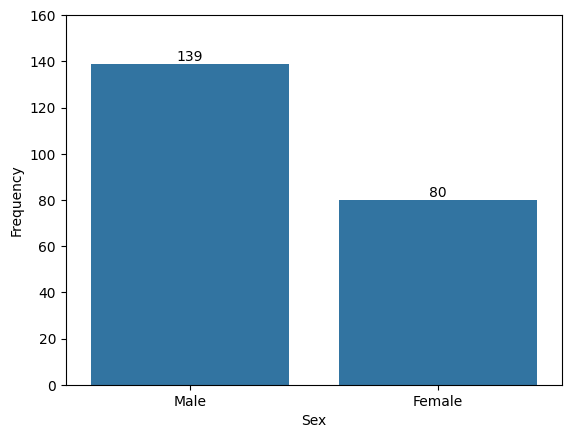

In [7]:
import seaborn as sns

ax = sns.barplot(x = Gender_freq.index,
                 y = Gender_freq.values)

ax.set(ylim = (0, 160),
       ylabel = 'Frequency')

ax.bar_label(ax.containers[0]);  # add labels in the graph (140, 60, for example)


In [8]:
print(myData.Income.max())
print(myData.Income.min())

167000
31000


In [9]:
import numpy as np
intervals = np.linspace(start = 30000, stop = 170000, num = 11)
print("intervals:  ", intervals)
# num 11 --> 11 evenly spaced numbers create 10 equal-wi bins
#        --> 11 edges/numbers define 10 equal-width bins




#pd.cut(....):  turns your numerical column into categorial categorial bins
#.value_counts(...): then counts how many rows fall in each bin.

Frequency = pd.cut(myData.Income, bins = np.linspace(30000, 170000, 11)).value_counts(sort = False)

Frequency

intervals:   [ 30000.  44000.  58000.  72000.  86000. 100000. 114000. 128000. 142000.
 156000. 170000.]


,count
Income,
"(30000.0, 44000.0]",22
"(44000.0, 58000.0]",52
"(58000.0, 72000.0]",46
"(72000.0, 86000.0]",34
"(86000.0, 100000.0]",43
"(100000.0, 114000.0]",13
"(114000.0, 128000.0]",2
"(128000.0, 142000.0]",4
"(142000.0, 156000.0]",2


In [10]:
Frequency_prop = pd.cut(myData.Income, bins = np.linspace(30000, 170000, 11)).value_counts(sort = False)

Frequency_prop

,count
Income,
"(30000.0, 44000.0]",22
"(44000.0, 58000.0]",52
"(58000.0, 72000.0]",46
"(72000.0, 86000.0]",34
"(86000.0, 100000.0]",43
"(100000.0, 114000.0]",13
"(114000.0, 128000.0]",2
"(128000.0, 142000.0]",4
"(142000.0, 156000.0]",2


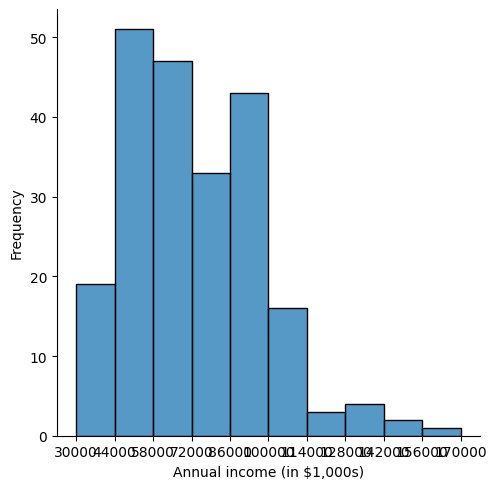

In [11]:
import seaborn as sns
ax = sns.displot(myData.Income,
                 bins = np.linspace(30000, 170000, 11))

ax.set(xticks = intervals,
       xlabel = 'Annual income (in $1,000s)',
       ylabel = 'Frequency')

### The above plot --> Positively skewed